In [110]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
import joblib
import streamlit as st
from pyngrok import ngrok
import os
import time
# 필요한 라이브러리는 최상단에 선언

In [52]:
# 조건 1
# 데이터 로드
# https://github.com/dongupak/DataML/raw/main/csv/life_expectancy.csv
url = 'https://github.com/dongupak/DataML/raw/main/csv/life_expectancy.csv'
df = pd.read_csv(url) # 데이터 프레임으로 저장
# print(df.info()) # 데이터프레임 확인
# print(df.head())

# 결측치 확인
print(df.isna())
# 결측치 제거
df = df.dropna()
# print(df.info())

# 기대수명을 예측하기 위한 독립변수 3개 자율 선택
# Country, GDP, BMI
# 데이터 분할
feature = ['Infant deaths', 'GDP', 'BMI']
X = df[feature].values
y = df['Life expectancy'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # 훈련 테스트 세트 분할
np.random.seed(42)

n_sample = np.random.choice(len(X_train), size=50, replace=False)
X_train_sampled = X_train[n_sample]
y_train_sampled = y_train[n_sample]

      Country   Year  Status  Life expectancy  Adult mortality  Infant deaths  \
0       False  False   False            False            False          False   
1       False  False   False            False            False          False   
2       False  False   False            False            False          False   
3       False  False   False            False            False          False   
4       False  False   False            False            False          False   
...       ...    ...     ...              ...              ...            ...   
2933    False  False   False            False            False          False   
2934    False  False   False            False            False          False   
2935    False  False   False            False            False          False   
2936    False  False   False            False            False          False   
2937    False  False   False            False            False          False   

      Alcohol  Percentage e

In [53]:
print(df.info()) # 데이터프레임 확인

<class 'pandas.core.frame.DataFrame'>
Index: 1649 entries, 0 to 2937
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          1649 non-null   object 
 1   Year                             1649 non-null   int64  
 2   Status                           1649 non-null   object 
 3   Life expectancy                  1649 non-null   float64
 4   Adult mortality                  1649 non-null   float64
 5   Infant deaths                    1649 non-null   int64  
 6   Alcohol                          1649 non-null   float64
 7   Percentage expenditure           1649 non-null   float64
 8   Hepatitis B                      1649 non-null   float64
 9   Measles                          1649 non-null   int64  
 10  BMI                              1649 non-null   float64
 11  Under-five deaths                1649 non-null   int64  
 12  Polio                    

In [54]:
print(df.head())

       Country  Year      Status  Life expectancy  Adult mortality  \
0  Afghanistan  2015  Developing             65.0            263.0   
1  Afghanistan  2014  Developing             59.9            271.0   
2  Afghanistan  2013  Developing             59.9            268.0   
3  Afghanistan  2012  Developing             59.5            272.0   
4  Afghanistan  2011  Developing             59.2            275.0   

   Infant deaths  Alcohol  Percentage expenditure  Hepatitis B  Measles  ...  \
0             62     0.01               71.279624         65.0     1154  ...   
1             64     0.01               73.523582         62.0      492  ...   
2             66     0.01               73.219243         64.0      430  ...   
3             69     0.01               78.184215         67.0     2787  ...   
4             71     0.01                7.097109         68.0     3013  ...   

   Polio  Total expenditure  Diphtheria  HIV/AIDS         GDP  Population  \
0    6.0             

In [89]:
# 조건 2
# 파이프라인 기반 모델 3종 학습 및 저장
# 1차 항 기본 선형 회귀 파이프라인
linear_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('regr', LinearRegression())
])
# 2차 다항 회귀 파이프라인(규제 없음->과대적합 유도)
poly_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(degree=3)),
    ('regr', LinearRegression())
])
# 3차 다항 회귀 + 릿지 규제 파이프라인
ridge_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(degree=3)),
    ('regr', Ridge(alpha=1.0))
])
# 세가지 모델을 pipeline_models로 묶기
pipeline_models = [
    ('Linear', linear_pipe),
    ('Poly', poly_pipe),
    ('Ridge', ridge_pipe)
]

# 학습
linear_pipe.fit(X_train_sampled, y_train_sampled)
poly_pipe.fit(X_train_sampled, y_train_sampled)
ridge_pipe.fit(X_train_sampled, y_train_sampled)

# 모델 객체들을 joblib을 통해 파일(.pkl)로 저장
joblib.dump(linear_pipe, 'linear_pipe.pkl')
joblib.dump(poly_pipe, 'poly_pipe.pkl')
joblib.dump(ridge_pipe, 'ridge_pipe.pkl')
print("파이프라인이 'pkl'로 성공적으로 저장되었습니다!")

파이프라인이 'pkl'로 성공적으로 저장되었습니다!


In [113]:
# 조건 3
# 성능 평가지표 테이블 출력
# 모델 세 개를 다루기 위해 for문 사용
linear_model = joblib.load("linear_pipe.pkl")
poly_model = joblib.load("poly_pipe.pkl")
ridge_model = joblib.load("ridge_pipe.pkl")
models = {
    "Linear": linear_model,
    "Poly": poly_model,
    "Ridge": ridge_model
}

results = []
for name, model in pipeline_models:
    # 예측
    train_pred = model.predict(X_train_sampled)
    test_pred = model.predict(X_test)

    # R2, MSE 계산
    train_r2 = r2_score(y_train_sampled, train_pred)
    test_r2 = r2_score(y_test, test_pred)
    train_mse = mean_squared_error(y_train_sampled, train_pred)
    test_mse = mean_squared_error(y_test, test_pred)

    # 복잡도 파악
    if name == 'Linear':
        complexity = X_train_sampled.shape[1]
    else:
        complexity = model.named_steps['poly'].get_feature_names_out().shape[0]

    results.append({
        'Model': name,
        'Train R^2': train_r2,
        'Test R^2': test_r2,
        'Train MSE': train_mse,
        'Test MSE': test_mse,
        '특성 개수': complexity
    })

# DataFrame으로 저장
results_df = pd.DataFrame(results)
st.dataframe(results_df) # streamlit 출력

# 성능 비교 시각화 지표
# R2 막대그래프
fig, ax = plt.subplots(figsize=(7,4))

ax.bar(
    results_df['Model'],
    results_df['Test R^2']
)

st.pyplot(fig)

# 모델 선택 인터페이스
model_choice = st.selectbox(
    "모델 선택",
    ["Linear", "Poly", "Ridge"]
)
selected_model = models[model_choice]



2026-06-17 14:29:42.109 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-17 14:29:42.110 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-17 14:29:42.111 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-17 14:29:42.130 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-17 14:29:42.234 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-17 14:29:42.235 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-17 14:29:42.237 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-17 14:29:42.239 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

In [115]:
# 조건 4
st.sidebar.header("Input Features")

infant = st.sidebar.slider(
    "Infant deaths",
    float(df['Infant deaths'].min()),
    float(df['Infant deaths'].max()),
    float(df['Infant deaths'].mean())
)

gdp = st.sidebar.slider(
    "GDP",
    float(df['GDP'].min()),
    float(df['GDP'].max()),
    float(df['GDP'].mean())
)

bmi = st.sidebar.slider(
    "BMI",
    float(df['BMI'].min()),
    float(df['BMI'].max()),
    float(df['BMI'].mean())
)

# 기대수명 결과 예측, 출력
input_data = np.array([
    [infant, gdp, bmi]
])
prediction = selected_model.predict(input_data)

st.title("기대 수명 예측")
st.metric(
    label="Life Expectancy",
    value=f"{prediction[0]:.2f} years"
)

2026-06-17 14:29:51.701 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-17 14:29:51.704 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-17 14:29:51.705 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-17 14:29:51.707 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-17 14:29:51.708 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-17 14:29:51.709 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-17 14:29:51.710 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-17 14:29:51.711 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

DeltaGenerator()

In [116]:
# 조건 5
!pip install streamlit pyngrok -q
from pyngrok import ngrok

ngrok.set_auth_token("3FGb9MJAuU7rmIVzi4qOxs8jEoE_78ELpqTzdmwEiiUYDPLyh")


In [128]:
%%writefile app.py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
import joblib
import streamlit as st
from pyngrok import ngrok
import os
import time
# 필요한 라이브러리는 최상단에 선언
# 조건 1
# 데이터 로드
url = 'https://github.com/dongupak/DataML/raw/main/csv/life_expectancy.csv'
df = pd.read_csv(url) # 데이터 프레임으로 저장
# print(df.info()) # 데이터프레임 확인
# print(df.head())

# 결측치 확인
print(df.isna())
# 결측치 제거
df = df.dropna()
# print(df.info())

# 기대수명을 예측하기 위한 독립변수 3개 자율 선택
# Country, GDP, BMI
# 데이터 분할
feature = ['Infant deaths', 'GDP', 'BMI']
X = df[feature].values
y = df['Life expectancy'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # 훈련 테스트 세트 분할
np.random.seed(42)

n_sample = np.random.choice(len(X_train), size=50, replace=False)
X_train_sampled = X_train[n_sample]
y_train_sampled = y_train[n_sample]

# 조건 2
# 파이프라인 기반 모델 3종 학습 및 저장
# 1차 항 기본 선형 회귀 파이프라인
linear_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('regr', LinearRegression())
])
# 2차 다항 회귀 파이프라인(규제 없음->과대적합 유도)
poly_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(degree=3)),
    ('regr', LinearRegression())
])
# 3차 다항 회귀 + 릿지 규제 파이프라인
ridge_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(degree=3)),
    ('regr', Ridge(alpha=1.0))
])
# 세가지 모델을 pipeline_models로 묶기
pipeline_models = [
    ('Linear', linear_pipe),
    ('Poly', poly_pipe),
    ('Ridge', ridge_pipe)
]

# 학습
linear_pipe.fit(X_train_sampled, y_train_sampled)
poly_pipe.fit(X_train_sampled, y_train_sampled)
ridge_pipe.fit(X_train_sampled, y_train_sampled)

# 모델 객체들을 joblib을 통해 파일(.pkl)로 저장
joblib.dump(linear_pipe, 'linear_pipe.pkl')
joblib.dump(poly_pipe, 'poly_pipe.pkl')
joblib.dump(ridge_pipe, 'ridge_pipe.pkl')
print("파이프라인이 'pkl'로 성공적으로 저장되었습니다!")

# 조건 3
# 성능 평가지표 테이블 출력
# 모델 세 개를 다루기 위해 for문 사용
linear_model = joblib.load("linear_pipe.pkl")
poly_model = joblib.load("poly_pipe.pkl")
ridge_model = joblib.load("ridge_pipe.pkl")
models = {
    "Linear": linear_model,
    "Poly": poly_model,
    "Ridge": ridge_model
}

results = []
for name, model in pipeline_models:
    # 예측
    train_pred = model.predict(X_train_sampled)
    test_pred = model.predict(X_test)

    # R2, MSE 계산
    train_r2 = r2_score(y_train_sampled, train_pred)
    test_r2 = r2_score(y_test, test_pred)
    train_mse = mean_squared_error(y_train_sampled, train_pred)
    test_mse = mean_squared_error(y_test, test_pred)

    # 복잡도 파악
    if name == 'Linear':
        complexity = X_train_sampled.shape[1]
    else:
        complexity = model.named_steps['poly'].get_feature_names_out().shape[0]

    results.append({
        'Model': name,
        'Train R^2': train_r2,
        'Test R^2': test_r2,
        'Train MSE': train_mse,
        'Test MSE': test_mse,
        '특성 개수': complexity
    })

# DataFrame으로 저장
results_df = pd.DataFrame(results)
st.dataframe(results_df) # streamlit 출력

# 성능 비교 시각화 지표
# R2 막대그래프
fig, ax = plt.subplots(figsize=(7,4))

ax.bar(
    results_df['Model'],
    results_df['Test R^2']
)

st.pyplot(fig)

# 모델 선택 인터페이스
model_choice = st.selectbox(
    "모델 선택",
    ["Linear", "Poly", "Ridge"]
)
selected_model = models[model_choice]

# 조건 4
st.sidebar.header("Input Features")

infant = st.sidebar.slider(
    "Infant deaths",
    float(df['Infant deaths'].min()),
    float(df['Infant deaths'].max()),
    float(df['Infant deaths'].mean())
)

gdp = st.sidebar.slider(
    "GDP",
    float(df['GDP'].min()),
    float(df['GDP'].max()),
    float(df['GDP'].mean())
)

bmi = st.sidebar.slider(
    "BMI",
    float(df['BMI'].min()),
    float(df['BMI'].max()),
    float(df['BMI'].mean())
)

# 기대수명 결과 예측, 출력
input_data = np.array([
    [infant, gdp, bmi]
])
prediction = selected_model.predict(input_data)

st.title("기대 수명 예측")
st.metric(
    label="Life Expectancy",
    value=f"{prediction[0]:.2f} years"
)

Overwriting app.py


In [131]:
# 1. 혹시 열려있을지 모르는 기존 터널 모두 닫기
ngrok.kill()

# 2. 인증 토큰 설정
ngrok.set_auth_token("3FGb9MJAuU7rmIVzi4qOxs8jEoE_78ELpqTzdmwEiiUYDPLyh")

# 3. Streamlit 실행 (서버 주소를 명시적으로 127.0.0.1로 고정하여 백그라운드 구동)
os.system("nohup streamlit run app.py --server.address 127.0.0.1 --server.port 8501 > /dev/null 2>&1 &")

# Streamlit 서버가 완전히 부팅될 때까지 3초간 대기
time.sleep(3)

# 4. ngrok 터널 연결 (8501 포트 열기)
public_url = ngrok.connect(8501, bind_tls=True)

print("=" * 60)
print(f"성공적으로 배포되었습니다! 아래 링크를 클릭하세요:\n{public_url}")
print("=" * 60)

성공적으로 배포되었습니다! 아래 링크를 클릭하세요:
NgrokTunnel: "https://chunk-five-portable.ngrok-free.dev" -> "http://localhost:8501"


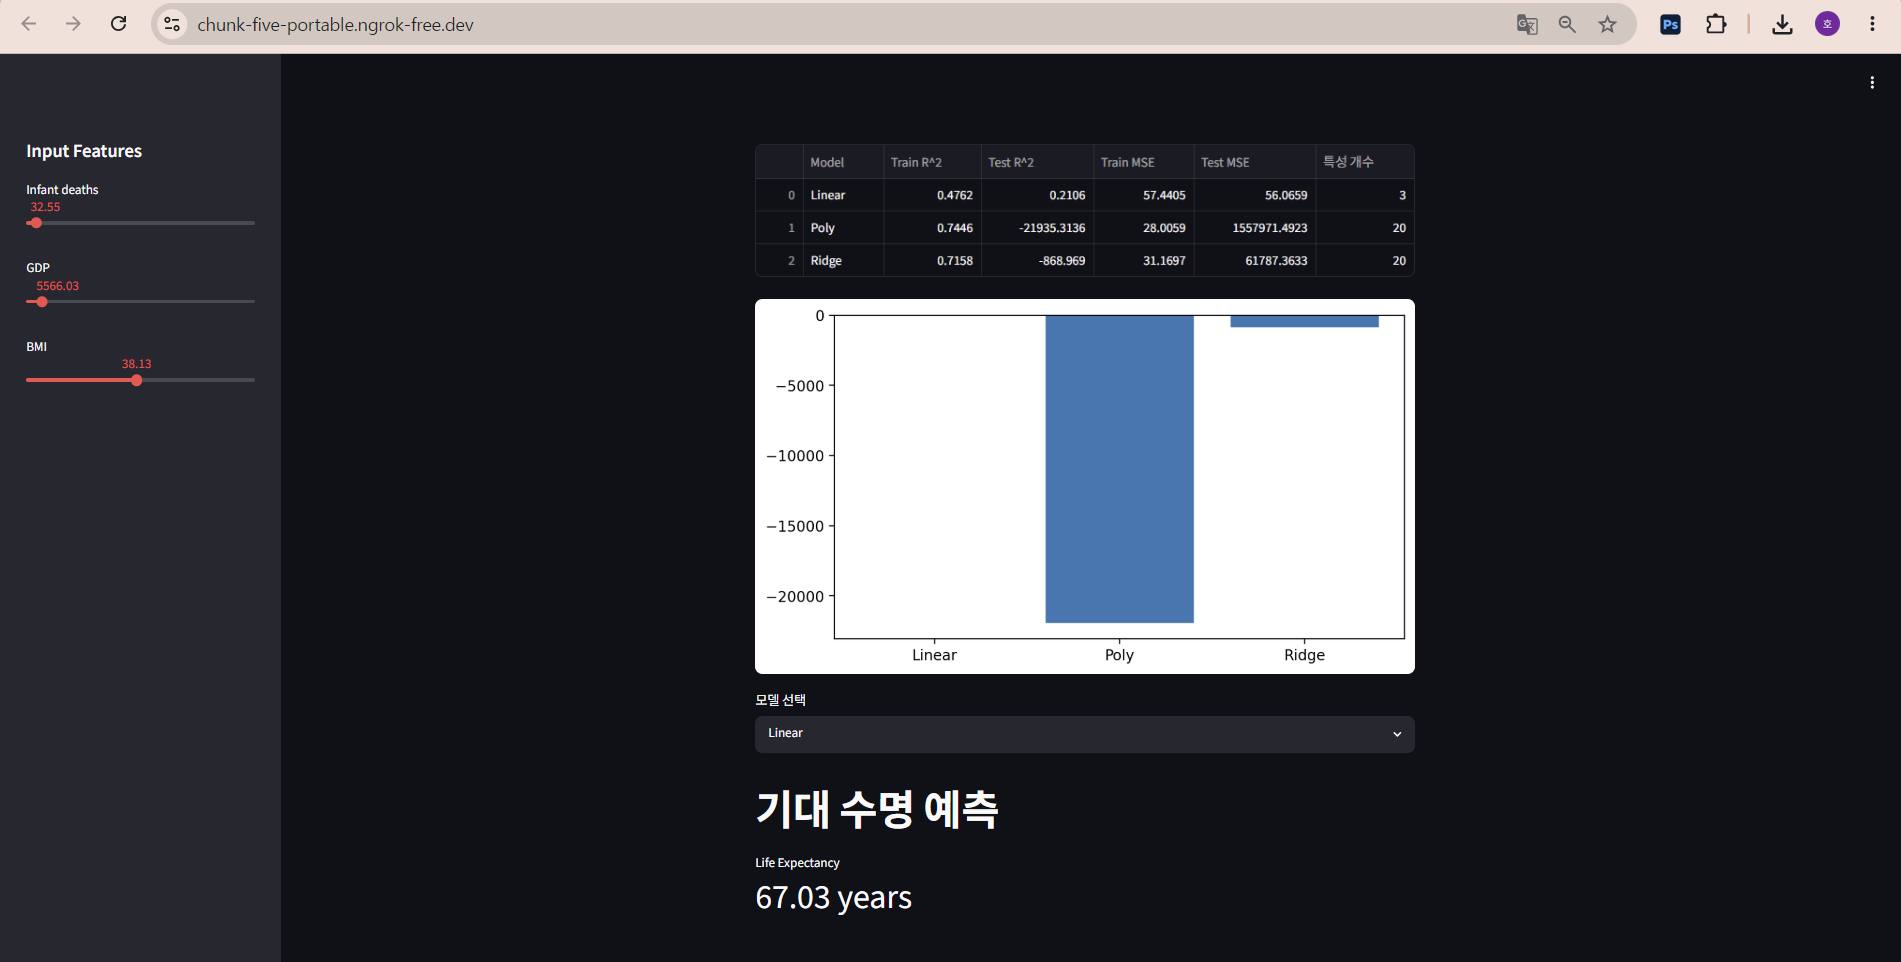